# 01 — EDA & Statistics

**Insurance Claim Fraud Detection & Action Recommendation System**

Purpose: inspect and understand the raw `fraud_oracle.csv` dataset before any
preprocessing decisions are made. This notebook performs **inspection only** — no
cleaning, encoding, resampling, feature engineering, splitting, or modelling happens
here. Those steps belong to `02_preprocessing_and_splitting.ipynb` onward.

> **Scope note (from the project README):** this dataset is a historical benchmark
> (Jan 1994 – Dec 1996). EDA findings describe patterns in this benchmark, not
> claims about current fraud trends.

**Run environment:** Google Colab, with the shared team Drive folder
`InsuranceFraudProject/` mounted. Every path is derived from `PROJECT_ROOT` below —
no local machine paths are used, and no state from another notebook is assumed.

**Contents**
1. Environment & Google Drive setup
2. Dataset loading (raw, unmodified)
3. Data-quality assessment
4. Target / fraud-class distribution
5. Feature exploration (categorical + numerical)
6. Historical / temporal analysis
7. Fraud-pattern exploration (bivariate)
8. Potential leakage / suspicious-feature review
9. EDA summary for Notebook 02

**Explicitly out of scope here:** fitting transformers, resampling, engineering
model-ready features, tuning models, selecting thresholds, calibrating
probabilities, or creating/accessing train/validation/test splits.

## 1. Environment & Google Drive Setup

Imports, plotting conventions, Drive mount, and centrally-defined paths. Every
later section reads paths from the variables defined here — nothing is
hard-coded inline.

In [1]:
"""Notebook 01 - EDA & Statistics: imports and plotting conventions."""
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display, Markdown

%matplotlib inline

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

# Fixed, colorblind-checked palette so every figure in this notebook uses the
# same encoding: blue/red are reserved for the target (legitimate/fraud),
# the full order is used for multi-category charts.
PALETTE = {
    "blue": "#2a78d6", "orange": "#eb6834", "aqua": "#1baf7a", "yellow": "#eda100",
    "magenta": "#e87ba4", "green": "#008300", "violet": "#4a3aa7", "red": "#e34948",
}
CATEGORICAL_ORDER = list(PALETTE.values())
TARGET_COLORS = {"Legitimate": PALETTE["blue"], "Fraud": PALETTE["red"]}

sns.set_style("white")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#c3c2b7",
    "axes.grid": True,
    "grid.color": "#e1e0d9",
    "grid.linewidth": 0.8,
    "axes.axisbelow": True,
    "font.size": 11,
})

saved_files = []  # every EDA output written to Drive is recorded here for the final recap
print("Libraries imported.")

Libraries imported.


### Mount Google Drive

The team's shared data and outputs live in a Drive folder, not in this Colab
session's local disk. Mounting is required before any path below can resolve.

In [2]:
try:
    from google.colab import drive
    drive.mount("/content/drive")
except ModuleNotFoundError as exc:
    raise RuntimeError(
        "This notebook is designed to run in Google Colab with the team's shared "
        "Drive mounted. `google.colab` is not available in this environment - open "
        "the notebook in Colab and re-run."
    ) from exc

Mounted at /content/drive


### Define project paths

All paths are derived from a single `PROJECT_ROOT`, matching the shared Drive
layout:

```
InsuranceFraudProject/
├── data/raw/fraud_oracle.csv
├── data/processed/
├── models/
├── results/figures/eda/
├── genai/
└── rubric/
```

This notebook only ever *reads* from `data/raw/` and *writes* to
`results/figures/eda/`.

In [3]:
PROJECT_ROOT = Path("/content/drive/MyDrive/InsuranceFraudProject")

DATA_RAW_DIR = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"  # not written to in this notebook
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_EDA_DIR = RESULTS_DIR / "figures" / "eda"

RAW_DATA_PATH = DATA_RAW_DIR / "fraud_oracle.csv"

# The only directory this notebook writes to (EDA figures + a leakage-review table).
FIGURES_EDA_DIR.mkdir(parents=True, exist_ok=True)

print("Project configuration")
print("-" * 60)
print(f"PROJECT_ROOT       : {PROJECT_ROOT}")
print(f"RAW_DATA_PATH       : {RAW_DATA_PATH}")
print(f"FIGURES_EDA_DIR     : {FIGURES_EDA_DIR}")
print(f"DATA_PROCESSED_DIR  : {DATA_PROCESSED_DIR}  (untouched by this notebook)")

Project configuration
------------------------------------------------------------
PROJECT_ROOT       : /content/drive/MyDrive/InsuranceFraudProject
RAW_DATA_PATH       : /content/drive/MyDrive/InsuranceFraudProject/data/raw/fraud_oracle.csv
FIGURES_EDA_DIR     : /content/drive/MyDrive/InsuranceFraudProject/results/figures/eda
DATA_PROCESSED_DIR  : /content/drive/MyDrive/InsuranceFraudProject/data/processed  (untouched by this notebook)


### Verify the raw dataset is present

Fail loudly and clearly here rather than letting a confusing error surface
later in `pd.read_csv`.

In [4]:
if not RAW_DATA_PATH.exists():
    raise FileNotFoundError(
        f"Could not find the raw dataset at:\n  {RAW_DATA_PATH}\n\n"
        "Checklist:\n"
        "  1. Confirm Google Drive is mounted (the previous cell ran without error).\n"
        "  2. Confirm the shared Drive folder 'InsuranceFraudProject' has been added "
        "to 'My Drive' (right-click -> 'Add shortcut to Drive'), not just visible "
        "under 'Shared with me'.\n"
        "  3. Confirm the file lives at data/raw/fraud_oracle.csv inside that folder.\n"
        "  4. Check spelling/casing of the folder and file names."
    )

file_size_mb = RAW_DATA_PATH.stat().st_size / (1024 ** 2)
print(f"Found raw dataset: {RAW_DATA_PATH}  ({file_size_mb:.2f} MB)")

Found raw dataset: /content/drive/MyDrive/InsuranceFraudProject/data/raw/fraud_oracle.csv  (3.45 MB)


## 2. Dataset Loading

Load the raw CSV as-is. No renaming, type coercion, or value changes happen in
this notebook — columns are reported exactly as they appear in the source file.

In [5]:
df = pd.read_csv(RAW_DATA_PATH)

print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")
print("\nColumn names:")
print(list(df.columns))

Rows    : 15,420
Columns : 33

Column names:
['Month', 'WeekOfMonth', 'DayOfWeek', 'Make', 'AccidentArea', 'DayOfWeekClaimed', 'MonthClaimed', 'WeekOfMonthClaimed', 'Sex', 'MaritalStatus', 'Age', 'Fault', 'PolicyType', 'VehicleCategory', 'VehiclePrice', 'FraudFound_P', 'PolicyNumber', 'RepNumber', 'Deductible', 'DriverRating', 'Days_Policy_Accident', 'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfVehicle', 'AgeOfPolicyHolder', 'PoliceReportFiled', 'WitnessPresent', 'AgentType', 'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars', 'Year', 'BasePolicy']


In [6]:
display(df.dtypes.rename("dtype").to_frame())
display(df.head())

,dtype
Month,object
WeekOfMonth,int64
DayOfWeek,object
Make,object
AccidentArea,object
DayOfWeekClaimed,object
MonthClaimed,object
WeekOfMonthClaimed,int64
Sex,object
MaritalStatus,object


,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,Age,Fault,PolicyType,VehicleCategory,VehiclePrice,FraudFound_P,PolicyNumber,RepNumber,Deductible,DriverRating,Days_Policy_Accident,Days_Policy_Claim,PastNumberOfClaims,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,21,Policy Holder,Sport - Liability,Sport,more than 69000,0,1,12,300,1,more than 30,more than 30,none,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,34,Policy Holder,Sport - Collision,Sport,more than 69000,0,2,15,400,4,more than 30,more than 30,none,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,47,Policy Holder,Sport - Collision,Sport,more than 69000,0,3,7,400,3,more than 30,more than 30,1,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,65,Third Party,Sedan - Liability,Sport,20000 to 29000,0,4,4,400,2,more than 30,more than 30,1,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,27,Third Party,Sport - Collision,Sport,more than 69000,0,5,3,400,1,more than 30,more than 30,none,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


### Verify the fraud target column exists

In [7]:
TARGET_COL = "FraudFound_P"

if TARGET_COL not in df.columns:
    raise KeyError(
        f"Expected fraud target column '{TARGET_COL}' was not found in the dataset.\n"
        f"Columns present: {list(df.columns)}\n"
        "Downstream notebooks cannot proceed without a confirmed target column - "
        "check whether the source file changed or the column was renamed."
    )

print(f"Target column '{TARGET_COL}' found. Unique values: {sorted(int(v) for v in df[TARGET_COL].unique())}")

Target column 'FraudFound_P' found. Unique values: [0, 1]


## 3. Data Quality Assessment

Findings are documented here, not fixed. Notebook 02 decides how each issue
should be handled during preprocessing.

### 3.1 Column-level summary: dtype, cardinality, missingness, dominant value

In [8]:
def build_quality_summary(data: pd.DataFrame) -> pd.DataFrame:
    """One row per column: dtype, cardinality, literal-NaN share, and dominant-value share.

    Placeholder-style missingness (e.g. a '0' or 'none' token standing in for a
    missing value) is not literal NaN and is investigated separately in 3.3, since
    pandas cannot infer those automatically.
    """
    n = len(data)
    rows = []
    for col in data.columns:
        s = data[col]
        mode = s.mode(dropna=True)
        top_val = mode.iloc[0] if not mode.empty else None
        top_freq = int((s == top_val).sum()) if top_val is not None else 0
        rows.append({
            "column": col,
            "dtype": s.dtype,
            "n_unique": s.nunique(dropna=True),
            "n_missing": int(s.isna().sum()),
            "pct_missing": round(100 * s.isna().sum() / n, 2),
            "top_value": top_val,
            "top_value_pct": round(100 * top_freq / n, 2),
        })
    return pd.DataFrame(rows).sort_values("pct_missing", ascending=False).reset_index(drop=True)

quality_summary = build_quality_summary(df)
display(quality_summary)

,column,dtype,n_unique,n_missing,pct_missing,top_value,top_value_pct
0,Month,object,12,0,0.0,Jan,9.15
1,WeekOfMonth,int64,5,0,0.0,3,23.61
2,DayOfWeek,object,7,0,0.0,Monday,16.96
3,Make,object,19,0,0.0,Pontiac,24.88
4,AccidentArea,object,2,0,0.0,Urban,89.64
5,DayOfWeekClaimed,object,8,0,0.0,Monday,24.36
6,MonthClaimed,object,13,0,0.0,Jan,9.38
7,WeekOfMonthClaimed,int64,5,0,0.0,2,24.12
8,Sex,object,2,0,0.0,Male,84.31
9,MaritalStatus,object,4,0,0.0,Married,68.90


### 3.2 Constant / near-constant columns

A column where one value covers almost every row carries little information
for classification and is worth flagging for review.

In [9]:
NEAR_CONSTANT_THRESHOLD = 99.0  # a single value covers >= 99% of rows

near_constant_cols = quality_summary.loc[
    quality_summary["top_value_pct"] >= NEAR_CONSTANT_THRESHOLD, "column"
].tolist()

print(f"Columns with a single dominant value covering >= {NEAR_CONSTANT_THRESHOLD}% of rows:")
print(near_constant_cols if near_constant_cols else "  None found.")

Columns with a single dominant value covering >= 99.0% of rows:
['Days_Policy_Claim', 'WitnessPresent']


### 3.3 Literal NaN vs. placeholder-token missingness

This dataset is known to encode some missing/invalid entries as placeholder
strings (e.g. a `'0'` category in a day/month field) rather than as NaN. Both
forms are checked separately.

In [10]:
total_missing = int(df.isna().sum().sum())
print(f"Total literal NaN cells in the raw dataset: {total_missing}")

SENTINEL_TOKENS = {"0", "none", "None", "NONE", "?", "-", "unknown", "Unknown", ""}

placeholder_rows = []
for col in df.select_dtypes(include="object").columns:
    hits = df[col].isin(SENTINEL_TOKENS)
    if hits.any():
        placeholder_rows.append({
            "column": col,
            "placeholder_tokens_found": sorted(df.loc[hits, col].unique().tolist()),
            "n_rows": int(hits.sum()),
            "pct_rows": round(100 * hits.sum() / len(df), 2),
        })

placeholder_report = pd.DataFrame(placeholder_rows)
display(placeholder_report)

Total literal NaN cells in the raw dataset: 0


,column,placeholder_tokens_found,n_rows,pct_rows
0,DayOfWeekClaimed,[0],1,0.01
1,MonthClaimed,[0],1,0.01
2,Days_Policy_Accident,[none],55,0.36
3,Days_Policy_Claim,[none],1,0.01
4,PastNumberOfClaims,[none],4352,28.22
5,NumberOfSuppliments,[none],7047,45.70




> some none values do not necessairly insinuate missing values depending on the column meaning and context, such as in past number of claims and number of supplements, which can be a real authentic value.



### 3.4 Duplicate rows and duplicate claim identifiers

In [11]:
n_duplicate_rows = int(df.duplicated().sum())
print(f"Fully duplicate rows: {n_duplicate_rows}")

ID_COL = "PolicyNumber"
if ID_COL in df.columns:
    n_duplicate_ids = int(df[ID_COL].duplicated().sum())
    print(f"Duplicate '{ID_COL}' values: {n_duplicate_ids} "
          f"(out of {df[ID_COL].nunique()} unique across {len(df)} rows)")
else:
    print(f"No '{ID_COL}' column found - skipping identifier-duplicate check.")

Fully duplicate rows: 0
Duplicate 'PolicyNumber' values: 0 (out of 15420 unique across 15420 rows)


### 3.5 Age consistency

`Age` (numeric) and `AgeOfPolicyHolder` (bucketed category) should agree. A
numeric `Age` of 0 is a known placeholder pattern in this dataset rather than a
real age — check what bucket those rows fall into.

In [12]:
if "Age" in df.columns:
    n_age_zero = int((df["Age"] == 0).sum())
    print(f"Rows with Age == 0: {n_age_zero} ({100 * n_age_zero / len(df):.2f}%)")
    print("\nAge summary statistics:")
    display(df["Age"].describe().to_frame())

if {"Age", "AgeOfPolicyHolder"}.issubset(df.columns):
    age_zero_buckets = df.loc[df["Age"] == 0, "AgeOfPolicyHolder"].value_counts()
    print("\nAgeOfPolicyHolder bucket for rows where numeric Age == 0:")
    display(age_zero_buckets.to_frame("count"))

Rows with Age == 0: 320 (2.08%)

Age summary statistics:


,Age
count,15420.000000
mean,39.855707
std,13.492377
min,0.000000
25%,31.000000
50%,38.000000
75%,48.000000
max,80.000000



AgeOfPolicyHolder bucket for rows where numeric Age == 0:


,count
AgeOfPolicyHolder,
16 to 17,320


### 3.6 Chronology check: accident month vs. claim month

`MonthClaimed` should not nominally precede `Month` (the accident month)
within the same policy year. Flagged rows are not corrected here — Notebook 02
decides whether they reflect genuine cross-year claims or data-entry issues.

In [13]:
MONTH_ORDER = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

if {"Month", "MonthClaimed"}.issubset(df.columns):
    month_rank = {m: i for i, m in enumerate(MONTH_ORDER)}
    valid_claimed = df["MonthClaimed"].isin(MONTH_ORDER)
    month_num = df["Month"].map(month_rank)
    claimed_num = df["MonthClaimed"].map(month_rank)

    same_year_anomaly = valid_claimed & (claimed_num < month_num)
    print(f"Rows with MonthClaimed nominally earlier than Month: "
          f"{same_year_anomaly.sum()} ({100 * same_year_anomaly.sum() / len(df):.2f}%)")
    print("(Not auto-corrected - some may be genuine cross-year claims; flagged for "
          "Notebook 02 to decide how to treat.)")

Rows with MonthClaimed nominally earlier than Month: 528 (3.42%)
(Not auto-corrected - some may be genuine cross-year claims; flagged for Notebook 02 to decide how to treat.)


### 3.7 `PolicyType` redundancy check

`PolicyType` looks like it may simply concatenate `VehicleCategory` and
`BasePolicy`. Checking this programmatically (rather than assuming it) tells
Notebook 02 whether to treat it as a multicollinearity concern.

In [14]:
if {"PolicyType", "VehicleCategory", "BasePolicy"}.issubset(df.columns):
    reconstructed = df["VehicleCategory"] + " - " + df["BasePolicy"]
    match_pct = 100 * (reconstructed == df["PolicyType"]).mean()
    print(f"'PolicyType' matches 'VehicleCategory - BasePolicy' in {match_pct:.1f}% of rows.")
    print("High agreement suggests PolicyType is largely redundant with the other two "
          "columns - a multicollinearity note for Notebook 02, not a data-quality bug.")

'PolicyType' matches 'VehicleCategory - BasePolicy' in 67.7% of rows.
High agreement suggests PolicyType is largely redundant with the other two columns - a multicollinearity note for Notebook 02, not a data-quality bug.


## 4. Target / Fraud Distribution

The project evaluates fraud detection with metrics appropriate for severe
class imbalance (PR-AUC, recall, precision) rather than accuracy — quantifying
that imbalance here is what justifies that choice downstream.

In [15]:
target_counts = df[TARGET_COL].value_counts().sort_index()
target_labels = {0: "Legitimate", 1: "Fraud"}
target_pct = (target_counts / target_counts.sum() * 100).round(2)

target_summary = pd.DataFrame({
    "label": [target_labels.get(i, str(i)) for i in target_counts.index],
    "count": target_counts.values,
    "pct": target_pct.values,
})
imbalance_ratio = target_counts[0] / target_counts[1]

display(target_summary)
print(f"Class imbalance ratio (legitimate : fraud) = {imbalance_ratio:.1f} : 1")

,label,count,pct
0,Legitimate,14497,94.01
1,Fraud,923,5.99


Class imbalance ratio (legitimate : fraud) = 15.7 : 1


Saved figure -> /content/drive/MyDrive/InsuranceFraudProject/results/figures/eda/target_distribution.png  (class balance for FraudFound_P)


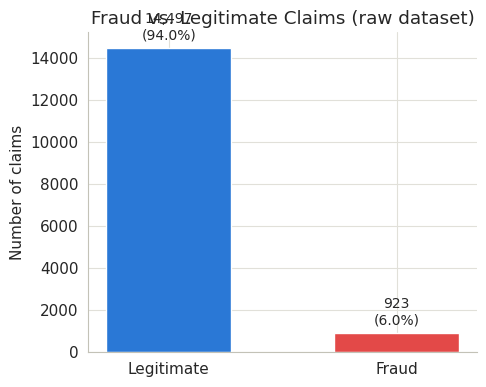

In [16]:
def save_figure(fig, filename: str, note: str = "") -> Path:
    """Save a figure to the EDA figures directory, record it, and print the path."""
    out_path = FIGURES_EDA_DIR / filename
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    saved_files.append(out_path)
    print(f"Saved figure -> {out_path}" + (f"  ({note})" if note else ""))
    return out_path


fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(
    target_summary["label"], target_summary["count"],
    color=[TARGET_COLORS["Legitimate"], TARGET_COLORS["Fraud"]],
    width=0.55,
)
for bar, pct in zip(bars, target_summary["pct"]):
    ax.annotate(
        f"{bar.get_height():,.0f}\n({pct:.1f}%)",
        xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
        xytext=(0, 4), textcoords="offset points",
        ha="center", va="bottom", fontsize=10,
    )

ax.set_ylabel("Number of claims")
ax.set_title("Fraud vs. Legitimate Claims (raw dataset)")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()

save_figure(fig, "target_distribution.png", note="class balance for FraudFound_P")
plt.show()

## 5. Feature Exploration

Prioritizing features plausibly relevant to fraud detection rather than
plotting every column. Categorical variables get frequency tables (flagging
rare categories); numerical variables get descriptive statistics, an outlier
scan, and distribution plots. Demographic variables (`Sex`, `MaritalStatus`,
`Age`) are described here as part of routine EDA, not used for any decisioning.

### 5.1 Categorical variables

In [17]:
def summarize_categorical(col: str, rare_threshold: float = 1.0) -> pd.DataFrame:
    """Frequency table for a categorical column; flags categories under `rare_threshold`%."""
    counts = df[col].value_counts(dropna=False)
    pct = (counts / len(df) * 100).round(2)
    out = pd.DataFrame({"count": counts, "pct": pct})
    out["rare_category"] = out["pct"] < rare_threshold
    return out


CATEGORICAL_FEATURES_OF_INTEREST = [c for c in [
    "Make", "AccidentArea", "Sex", "MaritalStatus", "Fault", "PolicyType",
    "VehicleCategory", "VehiclePrice", "BasePolicy", "PoliceReportFiled",
    "WitnessPresent", "AgentType", "AddressChange_Claim", "PastNumberOfClaims",
    "NumberOfSuppliments", "Days_Policy_Accident", "Days_Policy_Claim",
] if c in df.columns]

for col in CATEGORICAL_FEATURES_OF_INTEREST:
    print(f"\n--- {col} ---")
    display(summarize_categorical(col))


--- Make ---


,count,pct,rare_category
Make,,,
Pontiac,3837,24.88,False
Toyota,3121,20.24,False
Honda,2801,18.16,False
Mazda,2354,15.27,False
Chevrolet,1681,10.90,False
Accura,472,3.06,False
Ford,450,2.92,False
VW,283,1.84,False
Dodge,109,0.71,True



--- AccidentArea ---


,count,pct,rare_category
AccidentArea,,,
Urban,13822,89.64,False
Rural,1598,10.36,False



--- Sex ---


...

,count,pct,rare_category
NumberOfSuppliments,,,
none,7047,45.70,False
more than 5,3867,25.08,False
1 to 2,2489,16.14,False
3 to 5,2017,13.08,False



--- Days_Policy_Accident ---


,count,pct,rare_category
Days_Policy_Accident,,,
more than 30,15247,98.88,False
none,55,0.36,True
8 to 15,55,0.36,True
15 to 30,49,0.32,True
1 to 7,14,0.09,True



--- Days_Policy_Claim ---


,count,pct,rare_category
Days_Policy_Claim,,,
more than 30,15342,99.49,False
15 to 30,56,0.36,True
8 to 15,21,0.14,True
none,1,0.01,True


Saved figure -> /content/drive/MyDrive/InsuranceFraudProject/results/figures/eda/categorical_feature_overview.png  (Make (top 10) and VehiclePrice)


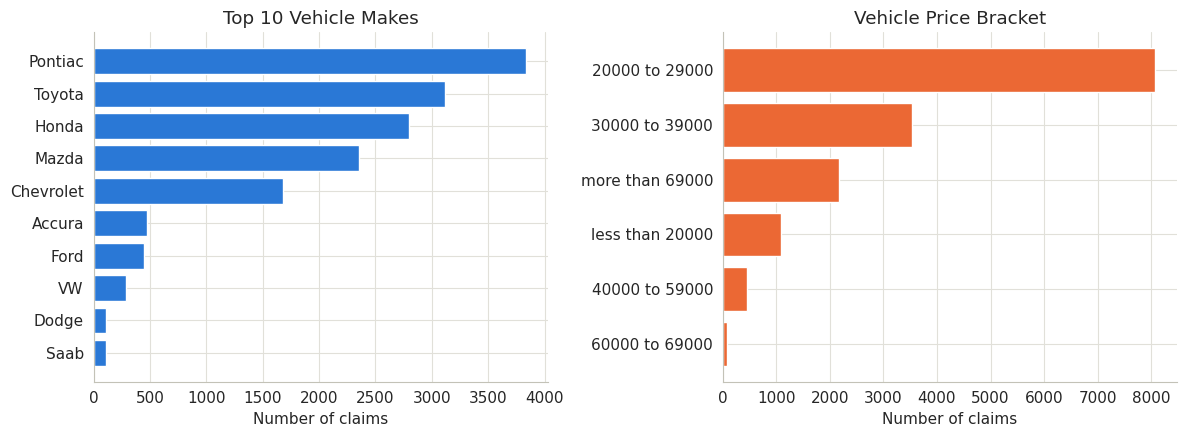

In [18]:
if {"Make", "VehiclePrice"}.issubset(df.columns):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    make_counts = df["Make"].value_counts().head(10)
    axes[0].barh(make_counts.index[::-1], make_counts.values[::-1], color=PALETTE["blue"])
    axes[0].set_title("Top 10 Vehicle Makes")
    axes[0].set_xlabel("Number of claims")

    price_counts = df["VehiclePrice"].value_counts()
    axes[1].barh(price_counts.index[::-1], price_counts.values[::-1], color=PALETTE["orange"])
    axes[1].set_title("Vehicle Price Bracket")
    axes[1].set_xlabel("Number of claims")

    for ax in axes:
        ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    save_figure(fig, "categorical_feature_overview.png", note="Make (top 10) and VehiclePrice")
    plt.show()

### 5.2 Numerical variables

In [19]:
NUMERIC_FEATURES_OF_INTEREST = [
    c for c in ["Age", "DriverRating", "Deductible", "WeekOfMonth", "WeekOfMonthClaimed", "RepNumber"]
    if c in df.select_dtypes(include=np.number).columns
]

display(df[NUMERIC_FEATURES_OF_INTEREST].describe().T)

,count,mean,std,min,25%,50%,75%,max
Age,15420.0,39.855707,13.492377,0.0,31.0,38.0,48.0,80.0
DriverRating,15420.0,2.487808,1.119453,1.0,1.0,2.0,3.0,4.0
Deductible,15420.0,407.704280,43.950998,300.0,400.0,400.0,400.0,700.0
WeekOfMonth,15420.0,2.788586,1.287585,1.0,2.0,3.0,4.0,5.0
WeekOfMonthClaimed,15420.0,2.693969,1.259115,1.0,2.0,3.0,4.0,5.0
RepNumber,15420.0,8.483268,4.599948,1.0,5.0,8.0,12.0,16.0


In [20]:
def iqr_outlier_count(col: str) -> int:
    """Count values outside 1.5x IQR from the quartiles - a documentation check, not a filter."""
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return int(((df[col] < lower) | (df[col] > upper)).sum())


for col in NUMERIC_FEATURES_OF_INTEREST:
    n_out = iqr_outlier_count(col)
    print(f"{col:<20} IQR-flagged values: {n_out} ({100 * n_out / len(df):.2f}%)")

Age                  IQR-flagged values: 547 (3.55%)
DriverRating         IQR-flagged values: 0 (0.00%)
Deductible           IQR-flagged values: 582 (3.77%)
WeekOfMonth          IQR-flagged values: 0 (0.00%)
WeekOfMonthClaimed   IQR-flagged values: 0 (0.00%)
RepNumber            IQR-flagged values: 0 (0.00%)


Saved figure -> /content/drive/MyDrive/InsuranceFraudProject/results/figures/eda/numerical_distributions.png


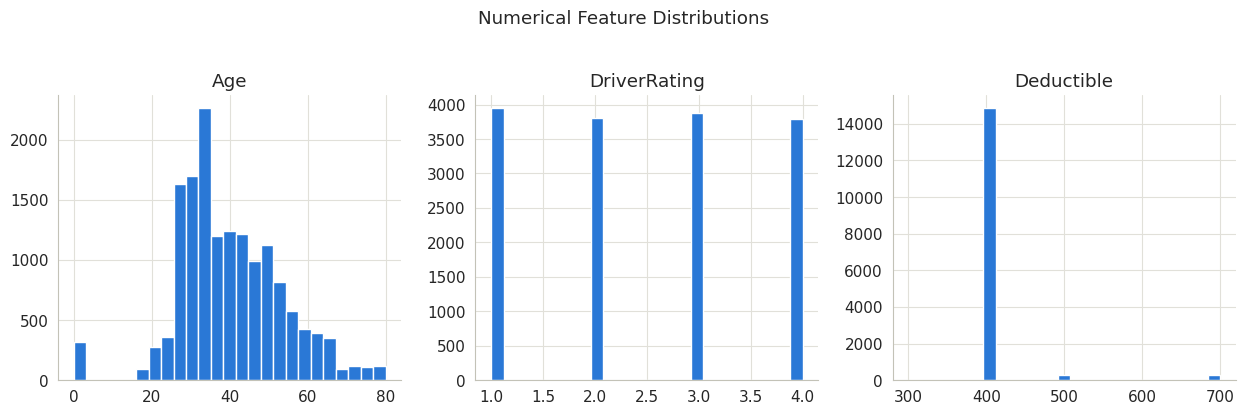

In [21]:
hist_cols = [c for c in ["Age", "DriverRating", "Deductible"] if c in NUMERIC_FEATURES_OF_INTEREST]

if hist_cols:
    fig, axes = plt.subplots(1, len(hist_cols), figsize=(4.2 * len(hist_cols), 4))
    axes = np.atleast_1d(axes)
    for ax, col in zip(axes, hist_cols):
        ax.hist(df[col].dropna(), bins=25, color=PALETTE["blue"], edgecolor="white")
        ax.set_title(col)
        ax.spines[["top", "right"]].set_visible(False)
    fig.suptitle("Numerical Feature Distributions", y=1.03)
    fig.tight_layout()
    save_figure(fig, "numerical_distributions.png")
    plt.show()

## 6. Historical / Temporal Analysis

The dataset covers claims from roughly 1994-1996. This section documents that
window explicitly so the project's framing — a historical benchmark / proof of
concept, not a model of present-day fraud — is grounded in the actual data
rather than asserted.

In [22]:
if "Year" not in df.columns:
    raise KeyError("Expected a 'Year' column for temporal analysis; not found in the dataset.")

year_counts = df["Year"].value_counts().sort_index()
display(year_counts.to_frame("n_claims"))
print(f"Years represented in the dataset: {sorted(int(y) for y in df['Year'].unique())}")

,n_claims
Year,
1994,6142
1995,5195
1996,4083


Years represented in the dataset: [1994, 1995, 1996]


Saved figure -> /content/drive/MyDrive/InsuranceFraudProject/results/figures/eda/claims_by_year.png


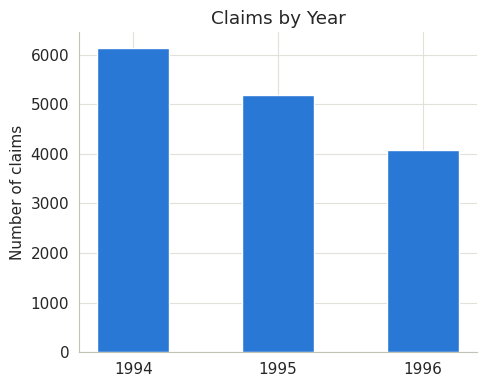

In [23]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(year_counts.index.astype(str), year_counts.values, color=PALETTE["blue"], width=0.5)
ax.set_ylabel("Number of claims")
ax.set_title("Claims by Year")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
save_figure(fig, "claims_by_year.png")
plt.show()

,n_claims,n_fraud,fraud_rate_pct
Year,,,
1994,6142,409,6.66
1995,5195,301,5.79
1996,4083,213,5.22


Saved figure -> /content/drive/MyDrive/InsuranceFraudProject/results/figures/eda/fraud_by_year.png


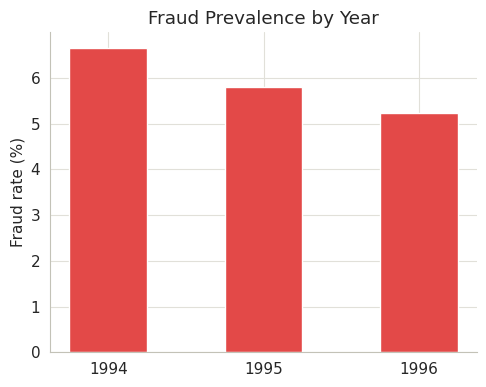

In [24]:
fraud_by_year = df.groupby("Year")[TARGET_COL].agg(n_claims="count", n_fraud="sum")
fraud_by_year["fraud_rate_pct"] = (fraud_by_year["n_fraud"] / fraud_by_year["n_claims"] * 100).round(2)
display(fraud_by_year)

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(fraud_by_year.index.astype(str), fraud_by_year["fraud_rate_pct"], color=PALETTE["red"], width=0.5)
ax.set_ylabel("Fraud rate (%)")
ax.set_title("Fraud Prevalence by Year")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
save_figure(fig, "fraud_by_year.png")
plt.show()

> **Interpretation note:** year-to-year differences here may reflect changes in
> this specific historical sample (reporting practices, sampling, data
> collection) as much as genuine fraud trends. With only three years of data,
> this section documents the dataset's temporal scope — it does not support
> claims about how insurance fraud has evolved since, or generalizes to
> present-day claims.

## 7. Fraud Patterns

Exploring whether the fraud label appears associated with claim, policy,
vehicle, and incident characteristics. These are descriptive, exploratory
summaries — associations here are not evidence of causal effects, and this
section does not perform feature selection.

In [25]:
def fraud_rate_by_category(col: str, min_count: int = 30) -> pd.DataFrame:
    """Per-category claim count and fraud rate.

    Categories below `min_count` are dropped from the *displayed* table because
    their fraud-rate estimate would be too noisy on this few observations to
    interpret meaningfully - the raw data itself is left untouched.
    """
    g = df.groupby(col)[TARGET_COL].agg(n_claims="count", n_fraud="sum")
    g["fraud_rate_pct"] = (g["n_fraud"] / g["n_claims"] * 100).round(2)
    return g[g["n_claims"] >= min_count].sort_values("fraud_rate_pct", ascending=False)


BIVARIATE_CATEGORICAL = [c for c in [
    "Fault", "PastNumberOfClaims", "AddressChange_Claim", "PoliceReportFiled",
    "WitnessPresent", "AgentType", "BasePolicy",
] if c in df.columns]

for col in BIVARIATE_CATEGORICAL:
    print(f"\n--- Fraud rate by {col} ---")
    display(fraud_rate_by_category(col))


--- Fraud rate by Fault ---


,n_claims,n_fraud,fraud_rate_pct
Fault,,,
Policy Holder,11230,886,7.89
Third Party,4190,37,0.88



--- Fraud rate by PastNumberOfClaims ---


,n_claims,n_fraud,fraud_rate_pct
PastNumberOfClaims,,,
none,4352,339,7.79
1,3573,222,6.21
2 to 4,5485,294,5.36
more than 4,2010,68,3.38



--- Fraud rate by AddressChange_Claim ---


...

,n_claims,n_fraud,fraud_rate_pct
WitnessPresent,,,
No,15333,920,6.00
Yes,87,3,3.45



--- Fraud rate by AgentType ---


,n_claims,n_fraud,fraud_rate_pct
AgentType,,,
External,15179,919,6.05
Internal,241,4,1.66



--- Fraud rate by BasePolicy ---


,n_claims,n_fraud,fraud_rate_pct
BasePolicy,,,
All Perils,4449,452,10.16
Collision,5962,435,7.30
Liability,5009,36,0.72


Saved figure -> /content/drive/MyDrive/InsuranceFraudProject/results/figures/eda/fraud_rate_by_key_categories.png


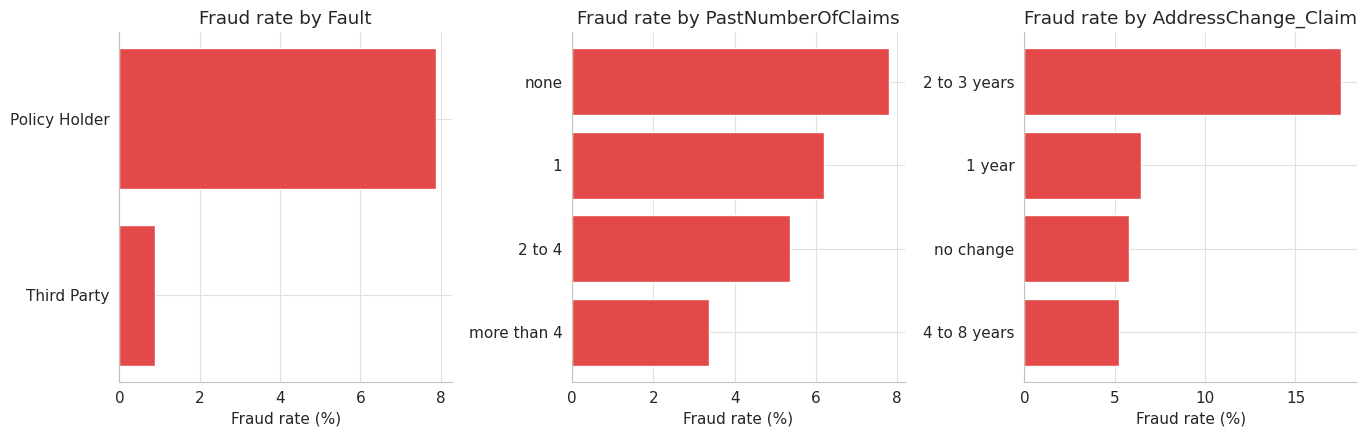

In [26]:
plot_cols = [c for c in ["Fault", "PastNumberOfClaims", "AddressChange_Claim"] if c in BIVARIATE_CATEGORICAL]

if plot_cols:
    fig, axes = plt.subplots(1, len(plot_cols), figsize=(4.6 * len(plot_cols), 4.5))
    axes = np.atleast_1d(axes)
    for ax, col in zip(axes, plot_cols):
        rates = fraud_rate_by_category(col)
        ax.barh(rates.index.astype(str)[::-1], rates["fraud_rate_pct"].values[::-1], color=PALETTE["red"])
        ax.set_title(f"Fraud rate by {col}")
        ax.set_xlabel("Fraud rate (%)")
        ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    save_figure(fig, "fraud_rate_by_key_categories.png")
    plt.show()

Saved figure -> /content/drive/MyDrive/InsuranceFraudProject/results/figures/eda/fraud_rate_by_driver_rating.png


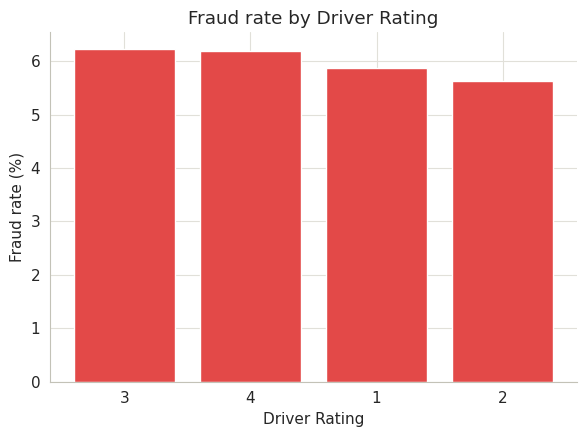

In [27]:
if "DriverRating" in df.columns:
    fig, ax = plt.subplots(figsize=(6, 4.5))
    rates = fraud_rate_by_category("DriverRating")
    ax.bar(rates.index.astype(str), rates["fraud_rate_pct"], color=PALETTE["red"])
    ax.set_title("Fraud rate by Driver Rating")
    ax.set_xlabel("Driver Rating")
    ax.set_ylabel("Fraud rate (%)")
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    save_figure(fig, "fraud_rate_by_driver_rating.png")
    plt.show()

#### Interpretation of "Fraud rate by Driver Rating":

*   The **'Fraud rate (%)'** is calculated by taking the count of claims flagged as fraudulent (`FraudFound_P = 1`) within each `DriverRating` category, dividing it by the total number of claims in that category, and then multiplying by 100.
*   This particular plot suggests that **`DriverRating` alone is not highly informative** for predicting fraud, as the fraud rate is consistently similar (between ~5.6% and ~6.2%) across all driver ratings. This indicates it may not be a strong univariate predictor of fraud in this dataset.

In [28]:
if NUMERIC_FEATURES_OF_INTEREST:
    numeric_by_target = df.groupby(TARGET_COL)[NUMERIC_FEATURES_OF_INTEREST].mean().T
    numeric_by_target.columns = ["Legitimate (mean)", "Fraud (mean)"]
    display(numeric_by_target)

,Legitimate (mean),Fraud (mean)
Age,39.956957,38.265439
DriverRating,2.485756,2.520043
Deductible,407.511899,410.725894
WeekOfMonth,2.792440,2.728061
WeekOfMonthClaimed,2.695799,2.665222
RepNumber,8.492033,8.345612


> Associations shown above are exploratory only. They describe patterns in
> this historical sample and are not causal claims, nor a feature-selection
> decision — that happens, with proper validation, in later notebooks.

## 7.5 Statistical Association Testing

Section 7 showed fraud rates varying across categories, but a rate difference
in a sample doesn't by itself confirm a real effect rather than noise, and it
says nothing about how strongly two variables relate to each other. This
section adds formal significance + effect-size testing for every feature
against the target, and a redundancy check among the features themselves.
As with the rest of this notebook, these are exploratory findings for
Notebook 02 and the modelling notebooks to act on — not a modelling or
feature-selection step.

## **Understanding Section 7.5: Finding Clues for Fraud**

Imagine you're a detective trying to figure out if a claim is fraudulent. Each piece of information (like 'Age', 'Car Make', 'Fault') is a 'clue' or 'feature'. Section 7.5 helps us answer two main questions about these clues:

1.  **How strong is the link between a clue and fraud?** (e.g., Is a certain car make seen more often in fraudulent claims?)
2.  **Are some clues essentially saying the same thing?** (e.g., If I know the 'VehicleCategory' and 'BasePolicy', do I really need to know 'PolicyType' too, or is it redundant?)

### **7.5.1 Categorical Features vs. Fraud: The Chi-Square Test & Cramér's V**

This part focuses on 'clues' that are categories, like 'Make' (Honda, Toyota) or 'Fault' (Policy Holder, Third Party). We want to see if the proportion of fraudulent claims changes depending on the category.

*   **The Chi-Square Test (p-value): Is there *any* link at all?**
    *   **Analogy:** You're looking at a group of suspects and notice that 80% of people with red hats are committing fraud, while only 5% of people with blue hats are. The chi-square test helps you decide if this difference is just a coincidence (random chance) or if there's a real, statistically significant pattern there. A very small 'p-value' (usually less than 0.05) suggests it's likely a real pattern, not just chance.
    *   **In simple terms:** It tells you if you can confidently say there *is* a relationship, even if it's a tiny one.

*   **Cramér's V: How *strong* is that link?**
    *   **Analogy:** The chi-square test says there's a link between red hats and fraud. But is it a super strong, always-true link, or just a slight tendency? Cramér's V gives you a number between 0 and 1:
        *   **0:** No relationship at all.
        *   **0.1 (weak):** There's a slight tendency.
        *   **0.3 (moderate):** There's a noticeable relationship.
        *   **0.5 or higher (strong):** There's a very strong relationship.
    *   **In simple terms:** This is the most important part! It tells you how useful that 'clue' is likely to be. Even if the p-value says there's a link, if Cramér's V is very low (e.g., 0.01), that clue isn't very strong or useful in practice.

#### **What does 'Reliable' mean for these tests?**

*   **Analogy:** Imagine you're doing a survey. If you ask only 3 people, and 1 of them has a red hat and committed fraud, you can't really make a confident statement about 'red hats' and 'fraud' in the whole population, right? The sample is too small.
*   **In simple terms:** The chi-square test needs enough data in each category to give a trustworthy result. 'Reliable = True' means there were enough observations (at least 5 in every sub-group within the categories) for the chi-square test and Cramér's V to be considered accurate. If it's 'False', the results might be misleading because some categories had too few data points.

### **7.5.2 Numeric Features vs. Fraud: Mann–Whitney U Test**

This part looks at 'clues' that are numbers, like 'Age' or 'Deductible'. We want to see if the average (or more precisely, median) value of these numbers is different for fraudulent claims compared to legitimate ones.

*   **Mann–Whitney U Test (p-value): Is there a difference between fraudulent and legitimate claims?**
    *   **Analogy:** You look at the 'Age' of people involved in fraud vs. legitimate claims. If the average age for fraud is 30 and for legitimate is 50, this test helps you confirm if that difference is statistically meaningful or just random.
    *   **Why not a simple average test?** Some numerical features might have weird distributions (like 'Age' having a bunch of zeros). The Mann–Whitney U test is good because it doesn't assume the data is perfectly bell-shaped; it looks at rankings instead of exact numbers, making it more robust to these irregularities.
*   **Effect Size (Rank-Biserial Correlation): How *big* is that difference?**
    *   Similar to Cramér's V, this value (between 0 and 1) tells you the strength of the difference. A higher number means a more distinct separation between fraudulent and legitimate claims based on that numeric feature.
*   **'Reliable' for numeric tests:** Similar logic as above; it ensures there were enough legitimate and fraudulent claims (at least 30 of each) to make a confident comparison.

### **7.5.3 Cramér's V Association Matrix (Feature Redundancy)**

This is about checking if different clues are actually telling you the same thing.

*   **Analogy:** If you have one clue that says 'suspect is wearing a hat' and another that says 'suspect is wearing a fedora', these clues are highly related! If you know they're wearing a fedora, you automatically know they're wearing a hat.
*   **In simple terms:** This creates a grid (matrix) where every categorical feature is compared against every other categorical feature using Cramér's V. If two features have a Cramér's V close to 1, it means they are very strongly related, almost redundant. This is important for later steps where you might want to simplify your set of clues, or avoid giving your model too much overlapping information.

### **7.5.4 Ranked Feature-Signal Summary**

This section pulls it all together!

*   **Analogy:** After collecting all your clues and evaluating how strong each one is, you'd rank them from most useful to least useful for solving the crime.
*   **In simple terms:** It takes all the Cramér's V values (for categorical features) and the rank-biserial effect sizes (for numerical features) and lists them from the strongest to the weakest relationship with 'fraud'. This table gives you a quick overview of which 'clues' seem to be the most promising for detecting fraud. However, it's still just a guide; models can sometimes find clever ways to use 'weak' clues when combined!

In essence, Section 7.5 helps us to statistically confirm the patterns we see in the data and prioritize which features might be most important for building a fraud detection model later on, while also identifying potential redundancies.

### 7.5.1 Categorical features vs. fraud: chi-square + Cramér's V

For every categorical feature (excluding the `PolicyNumber` / `RepNumber`
identifiers and the target itself), build a contingency table against
`FraudFound_P` and test independence with the chi-square test. The p-value
alone doesn't say how *strong* an association is, so each test is paired with
Cramér's V (bias-corrected) as an effect size. Tests where the smallest
expected cell count falls below 5 — the standard validity threshold for a
chi-square test — are flagged `reliable = False` rather than silently trusted,
in the same spirit as the `min_count` guard used in `fraud_rate_by_category`.

In [29]:
def cramers_v(x: pd.Series, y: pd.Series) -> float:
    """Bias-corrected Cramer's V (Bergsma, 2013): association effect size for two
    categorical variables, 0 (no association) to 1 (perfect association), symmetric
    in x/y. The bias correction removes the small-sample upward bias of the raw
    statistic, which matters here given how many low-count categories this dataset has.
    """
    table = pd.crosstab(x, y)
    if table.shape[0] < 2 or table.shape[1] < 2:
        return np.nan  # a constant column has no association to measure
    chi2 = stats.chi2_contingency(table, correction=False)[0]
    n = table.to_numpy().sum()
    r, k = table.shape
    phi2 = chi2 / n
    phi2_corr = max(0.0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    r_corr = r - ((r - 1) ** 2) / (n - 1)
    k_corr = k - ((k - 1) ** 2) / (n - 1)
    denom = min(k_corr - 1, r_corr - 1)
    return float(np.sqrt(phi2_corr / denom)) if denom > 0 else np.nan


def chi2_test_vs_target(col: str, min_expected: float = 5.0) -> dict:
    """Chi-square test of independence + Cramer's V for one categorical feature vs. the target."""
    table = pd.crosstab(df[col], df[TARGET_COL])
    if table.shape[0] < 2:
        return {"feature": col, "chi2": np.nan, "p_value": np.nan, "cramers_v": np.nan,
                "n_levels": table.shape[0], "min_expected_count": np.nan, "reliable": False}
    chi2, p_value, _dof, expected = stats.chi2_contingency(table)
    return {
        "feature": col,
        "chi2": chi2,
        "p_value": p_value,
        "cramers_v": cramers_v(df[col], df[TARGET_COL]),
        "n_levels": table.shape[0],
        "min_expected_count": expected.min(),
        "reliable": bool(expected.min() >= min_expected),
    }


EXCLUDE_FROM_ASSOCIATION_TESTS = {"PolicyNumber", "RepNumber", TARGET_COL}
CHI2_CATEGORICAL_FEATURES = [
    c for c in df.select_dtypes(include="object").columns
    if c not in EXCLUDE_FROM_ASSOCIATION_TESTS
]

# DriverRating is stored numerically but is a small, fixed ordinal scale (1-4) -
# genuinely categorical for association-testing purposes, and the specific feature
# this project wants checked here (see markdown above).
if "DriverRating" in df.columns and "DriverRating" not in CHI2_CATEGORICAL_FEATURES:
    CHI2_CATEGORICAL_FEATURES.append("DriverRating")

chi2_results = pd.DataFrame(chi2_test_vs_target(c) for c in CHI2_CATEGORICAL_FEATURES)
chi2_results = chi2_results.sort_values("cramers_v", ascending=False).reset_index(drop=True)

n_unreliable = int((~chi2_results["reliable"]).sum())
display(chi2_results)
print(f"{n_unreliable} feature(s) flagged unreliable (min expected cell count < 5).")

,feature,chi2,p_value,cramers_v,n_levels,min_expected_count,reliable
0,PolicyType,437.401870,1.848256e-89,0.166880,9,0.059857,False
1,BasePolicy,402.851921,3.325192e-88,0.161237,3,266.305253,True
2,VehicleCategory,290.942140,6.648398e-64,0.136892,3,23.404215,True
3,Fault,264.953824,1.428036e-59,0.131146,2,250.802205,True
4,AddressChange_Claim,104.733773,9.652105e-22,0.080827,5,0.239429,False
5,VehiclePrice,67.768295,2.983598e-13,0.063803,6,5.207588,True
6,PastNumberOfClaims,53.500831,1.433718e-11,0.057230,4,120.313230,True
7,Make,59.809999,2.195889e-06,0.052072,19,0.059857,False
8,MonthClaimed,42.266750,3.003256e-05,0.044305,13,0.059857,False
9,AgeOfPolicyHolder,33.003254,6.150520e-05,0.040269,9,0.897860,False


11 feature(s) flagged unreliable (min expected cell count < 5).


In [30]:
def _fmt_result(row) -> str:
    return f"chi2={row['chi2']:.1f}, p={row['p_value']:.3g}, Cramer's V={row['cramers_v']:.3f}"


def _effect_label(v: float) -> str:
    """Cramer's V -> a descriptive label, so interpretation text reflects the actual
    computed value rather than asserting a fixed conclusion regardless of the data."""
    if pd.isna(v):
        return "undefined"
    if v >= 0.5:
        return "strong"
    if v >= 0.3:
        return "moderate"
    if v >= 0.1:
        return "weak"
    return "negligible"


interp_lines = [
    "**How to read this table:** the chi-square `p_value` tells us whether the "
    "feature and the fraud label are independent (small p -> probably not "
    "independent); Cramer's V tells us how strong that association is, roughly: "
    "~0 none, ~0.1 weak, ~0.3 moderate, ~0.5+ strong. "
    f"With n = {len(df):,} rows, even a very small, practically meaningless effect "
    "can produce a 'significant' p-value - **Cramer's V, not the p-value alone, "
    "should drive interpretation here.**",
]

fault_row = chi2_results.loc[chi2_results["feature"] == "Fault"]
if not fault_row.empty:
    r = fault_row.iloc[0]
    label = _effect_label(r["cramers_v"])
    sig = "significant" if pd.notna(r["p_value"]) and r["p_value"] < 0.05 else "not significant at p < 0.05"
    interp_lines.append(
        f"- `Fault` shows a **{label}** association ({sig}; {_fmt_result(r)}) on this "
        "run. On the full 15,420-row dataset this is expected to be one of the "
        "strongest univariate signals, consistent with it being closely tied to the "
        "fraud-determination process itself (see the leakage note for `Fault` in "
        "Section 8)."
    )

driver_rating_row = chi2_results.loc[chi2_results["feature"] == "DriverRating"]
if not driver_rating_row.empty:
    r = driver_rating_row.iloc[0]
    label = _effect_label(r["cramers_v"])
    interp_lines.append(
        f"- `DriverRating` shows a **{label}** association ({_fmt_result(r)}) - "
        "expected to be near-negligible here, consistent with the flat fraud rate "
        "seen in the \"Fraud rate by Driver Rating\" chart above."
    )

interp_lines.append(
    "- **Low Cramer's V does not justify dropping a feature.** These are marginal, "
    "one-feature-at-a-time tests; gradient-boosted trees can still extract signal "
    "from interactions between individually weak features. Final feature relevance "
    "is deferred to per-model SHAP importance in later notebooks."
)

display(Markdown("\n".join(interp_lines)))

**How to read this table:** the chi-square `p_value` tells us whether the feature and the fraud label are independent (small p -> probably not independent); Cramer's V tells us how strong that association is, roughly: ~0 none, ~0.1 weak, ~0.3 moderate, ~0.5+ strong. With n = 15,420 rows, even a very small, practically meaningless effect can produce a 'significant' p-value - **Cramer's V, not the p-value alone, should drive interpretation here.**
- `Fault` shows a **weak** association (significant; chi2=265.0, p=1.43e-59, Cramer's V=0.131) on this run. On the full 15,420-row dataset this is expected to be one of the strongest univariate signals, consistent with it being closely tied to the fraud-determination process itself (see the leakage note for `Fault` in Section 8).
- `DriverRating` shows a **negligible** association (chi2=1.6, p=0.648, Cramer's V=0.000) - expected to be near-negligible here, consistent with the flat fraud rate seen in the "Fraud rate by Driver Rating" chart above.
- **Low Cramer's V does not justify dropping a feature.** These are marginal, one-feature-at-a-time tests; gradient-boosted trees can still extract signal from interactions between individually weak features. Final feature relevance is deferred to per-model SHAP importance in later notebooks.

### 7.5.2 Numeric features vs. fraud: Mann–Whitney U

The numeric fields here are mostly ordinal-like or discrete-tiered
(`DriverRating` 1–4, `Deductible` fixed tiers, `WeekOfMonth` /
`WeekOfMonthClaimed` 1–5) rather than continuous and normally distributed, and
`Age` carries a known zero-value placeholder spike (Section 3.5) that would
distort a mean/variance-based test. The Mann–Whitney U test compares the two
groups' rank distributions instead of their means, so it doesn't assume
normality and isn't thrown off by that spike. `Age == 0` rows are excluded
from the `Age` test specifically and the count is reported, not silently
dropped from the dataset. `RepNumber` is included here for completeness even
though it's flagged as an operational identifier in Section 8 — a null
univariate result for it would itself support that concern.

In [31]:
def mannwhitney_vs_target(col: str, exclude_zero: bool = False) -> dict:
    """Mann-Whitney U test comparing a numeric feature's distribution between fraud
    and legitimate claims - rank-based rather than a t-test (see markdown above).
    """
    values = df[col]
    mask = values.notna()
    n_excluded = 0
    if exclude_zero:
        n_excluded = int((values == 0).sum())
        mask &= values != 0

    legit = values[mask & (df[TARGET_COL] == 0)]
    fraud = values[mask & (df[TARGET_COL] == 1)]
    u_stat, p_value = stats.mannwhitneyu(legit, fraud, alternative="two-sided")

    return {
        "feature": col,
        "median_legit": legit.median(),
        "median_fraud": fraud.median(),
        "U": u_stat,
        "p_value": p_value,
        "n_legit": len(legit),
        "n_fraud": len(fraud),
        "n_excluded_placeholder": n_excluded,
        "reliable": bool(min(len(legit), len(fraud)) >= 30),  # same min_count=30 convention as Section 7
    }


mannwhitney_results = pd.DataFrame(
    mannwhitney_vs_target(c, exclude_zero=(c == "Age")) for c in NUMERIC_FEATURES_OF_INTEREST
).sort_values("p_value").reset_index(drop=True)

display(mannwhitney_results[[
    "feature", "median_legit", "median_fraud", "U", "p_value",
    "n_excluded_placeholder", "reliable",
]])

,feature,median_legit,median_fraud,U,p_value,n_excluded_placeholder,reliable
0,Deductible,400.0,400.0,6470472.0,3.789297e-07,0,True
1,Age,39.0,37.0,6680280.5,6.505809e-03,320,True
2,WeekOfMonth,3.0,3.0,6880306.0,1.380445e-01,0,True
3,RepNumber,8.0,8.0,6812766.5,3.496549e-01,0,True
4,DriverRating,2.0,3.0,6575957.0,3.675310e-01,0,True
5,WeekOfMonthClaimed,3.0,3.0,6773903.5,5.135154e-01,0,True


In [32]:
strongest = mannwhitney_results.iloc[0]
display(Markdown(
    f"`{strongest['feature']}` shows the strongest legit-vs-fraud separation "
    f"(median {strongest['median_legit']:.1f} vs. {strongest['median_fraud']:.1f}, "
    f"p = {strongest['p_value']:.3g}). As with the categorical tests above, this is "
    "marginal and exploratory, not a feature-selection decision."
))

`Deductible` shows the strongest legit-vs-fraud separation (median 400.0 vs. 400.0, p = 3.79e-07). As with the categorical tests above, this is marginal and exploratory, not a feature-selection decision.

### 7.5.3 Cramér's V association matrix (feature redundancy)

Section 3.7 found by direct inspection that `PolicyType` is largely a
concatenation of `VehicleCategory` and `BasePolicy`. This section runs that
same idea systematically across all categorical features — plus
`AgeOfPolicyHolder`, `AgeOfVehicle`, `NumberOfCars`, and `Age` itself (included
here despite being numeric, specifically to surface its expected redundancy
with `AgeOfPolicyHolder`) — to catch any other duplicated or near-duplicated
information. This doesn't affect a single decision-tree split the way it would
a linear model, but it matters for encoding choices and interpretability from
Notebook 02 onward.

Saved figure -> /content/drive/MyDrive/InsuranceFraudProject/results/figures/eda/cramers_v_association_matrix.png  (feature-vs-feature redundancy screen)


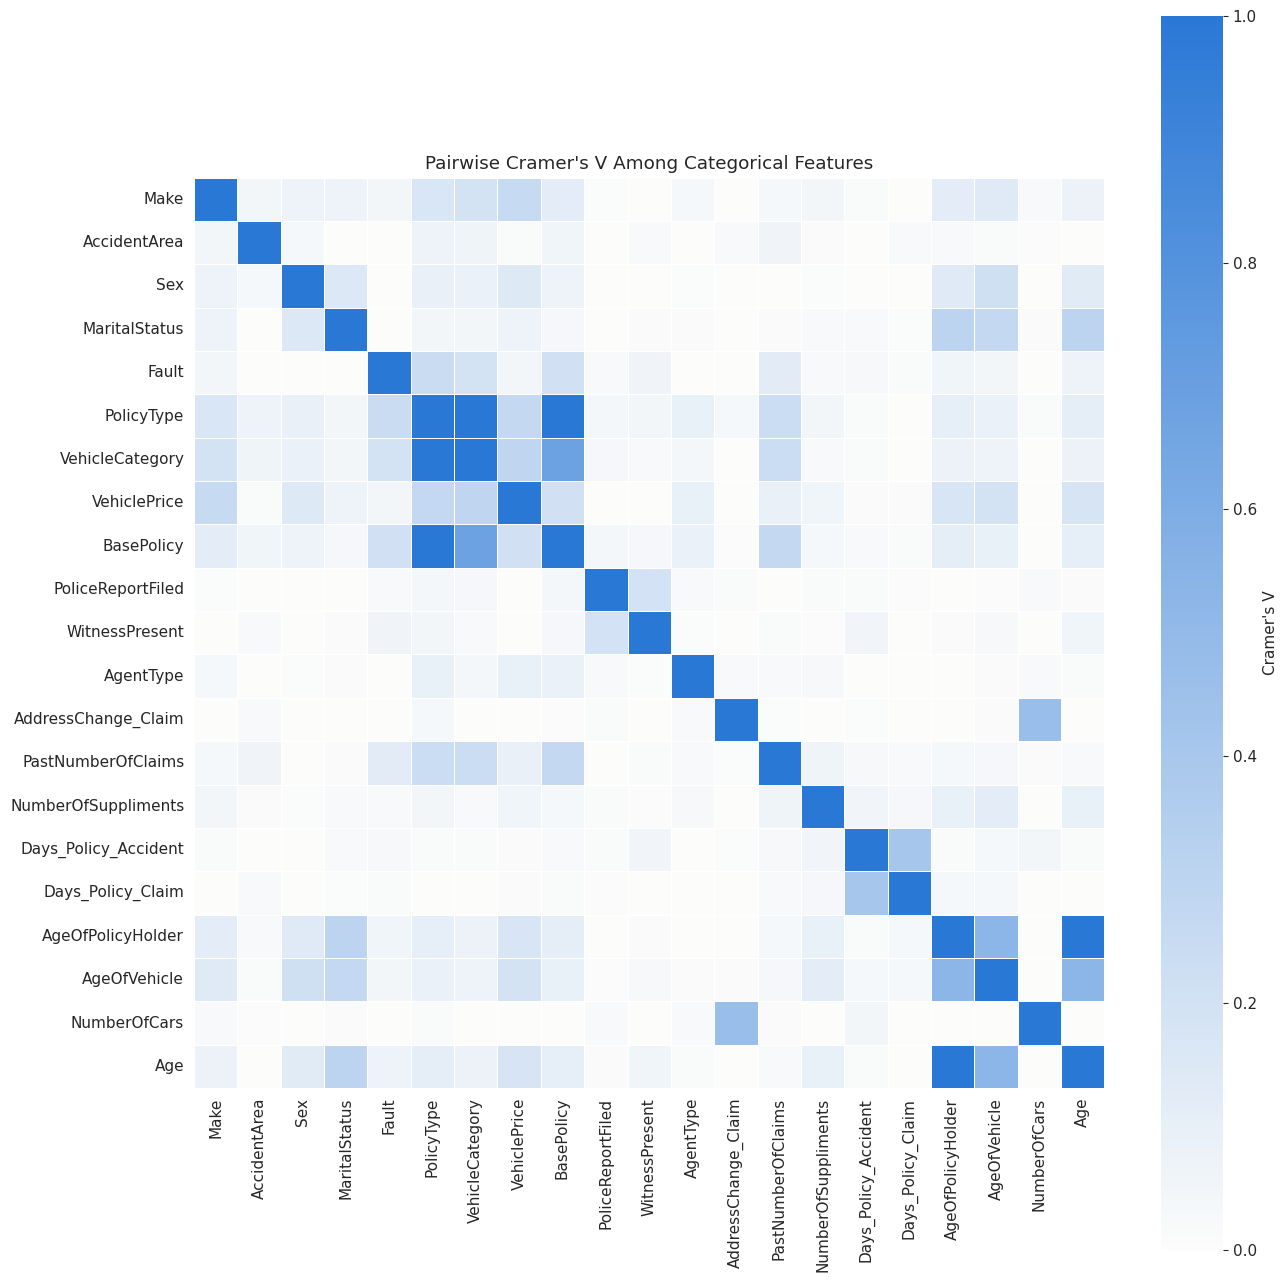

In [33]:
ASSOCIATION_MATRIX_FEATURES = list(CATEGORICAL_FEATURES_OF_INTEREST)
for extra in ["AgeOfPolicyHolder", "AgeOfVehicle", "NumberOfCars", "Age"]:
    if extra in df.columns and extra not in ASSOCIATION_MATRIX_FEATURES:
        ASSOCIATION_MATRIX_FEATURES.append(extra)


def build_cramers_v_matrix(columns: list) -> pd.DataFrame:
    """Symmetric matrix of pairwise (bias-corrected) Cramer's V between features."""
    matrix = pd.DataFrame(index=columns, columns=columns, dtype=float)
    for i, col_i in enumerate(columns):
        for col_j in columns[i:]:
            v = cramers_v(df[col_i], df[col_j])
            matrix.loc[col_i, col_j] = v
            matrix.loc[col_j, col_i] = v
    return matrix


association_matrix = build_cramers_v_matrix(ASSOCIATION_MATRIX_FEATURES)

from matplotlib.colors import LinearSegmentedColormap
blue_sequential = LinearSegmentedColormap.from_list("blue_sequential", ["#fcfcfb", PALETTE["blue"]])

fig, ax = plt.subplots(figsize=(0.55 * len(ASSOCIATION_MATRIX_FEATURES) + 2,
                                 0.55 * len(ASSOCIATION_MATRIX_FEATURES) + 2))
sns.heatmap(
    association_matrix, cmap=blue_sequential, vmin=0, vmax=1, square=True,
    linewidths=0.5, linecolor="white", cbar_kws={"label": "Cramer's V"}, ax=ax,
)
ax.set_title("Pairwise Cramer's V Among Categorical Features")
fig.tight_layout()
save_figure(fig, "cramers_v_association_matrix.png", note="feature-vs-feature redundancy screen")
plt.show()

In [34]:
HIGH_ASSOCIATION_THRESHOLD = 0.5

pairs = []
cols = ASSOCIATION_MATRIX_FEATURES
for i, a in enumerate(cols):
    for b in cols[i + 1:]:
        v = association_matrix.loc[a, b]
        if pd.notna(v) and v > HIGH_ASSOCIATION_THRESHOLD:
            pairs.append({"feature_a": a, "feature_b": b, "cramers_v": round(float(v), 3)})

high_association_pairs = pd.DataFrame(pairs, columns=["feature_a", "feature_b", "cramers_v"])
high_association_pairs = high_association_pairs.sort_values("cramers_v", ascending=False).reset_index(drop=True)
display(high_association_pairs)

if high_association_pairs.empty:
    msg = f"No feature pairs exceeded the Cramer's V > {HIGH_ASSOCIATION_THRESHOLD} threshold in this run."
else:
    pair_lines = "\n".join(
        f"- `{r.feature_a}` ↔ `{r.feature_b}`: V = {r.cramers_v:.3f}"
        for r in high_association_pairs.itertuples()
    )
    msg = (
        f"**High-association pairs (Cramer's V > {HIGH_ASSOCIATION_THRESHOLD}):** "
        "multicollinearity notes for Notebook 02 to make a decision on (e.g. drop "
        "one of the pair, combine them, or keep both and rely on model-level feature "
        "importance) — not leakage concerns on their own, and nothing is dropped here.\n\n"
        + pair_lines
    )
display(Markdown(msg))

,feature_a,feature_b,cramers_v
0,PolicyType,VehicleCategory,1.000
1,PolicyType,BasePolicy,1.000
2,AgeOfPolicyHolder,Age,0.998
3,VehicleCategory,BasePolicy,0.681
4,AgeOfVehicle,Age,0.535
5,AgeOfPolicyHolder,AgeOfVehicle,0.534


**High-association pairs (Cramer's V > 0.5):** multicollinearity notes for Notebook 02 to make a decision on (e.g. drop one of the pair, combine them, or keep both and rely on model-level feature importance) — not leakage concerns on their own, and nothing is dropped here.

- `PolicyType` ↔ `VehicleCategory`: V = 1.000
- `PolicyType` ↔ `BasePolicy`: V = 1.000
- `AgeOfPolicyHolder` ↔ `Age`: V = 0.998
- `VehicleCategory` ↔ `BasePolicy`: V = 0.681
- `AgeOfVehicle` ↔ `Age`: V = 0.535
- `AgeOfPolicyHolder` ↔ `AgeOfVehicle`: V = 0.534

### 7.5.4 Ranked feature-signal summary

Combines the categorical results (Cramér's V) and numeric results
(rank-biserial effect size, derived from the Mann–Whitney U statistic — a
normalized 0–1 effect size comparable in spirit to Cramér's V) into one ranked
view of which features carry the most univariate fraud signal in this
dataset. This is the headline screening artifact from this section: useful
for Notebook 02 and the report, not a feature-selection step in itself.

In [35]:
def rank_biserial_effect(u_stat: float, n1: int, n2: int) -> float:
    """Rank-biserial correlation from a Mann-Whitney U statistic - a normalized
    (0-1 magnitude) effect size comparable in spirit to Cramer's V."""
    return abs(1 - (2 * u_stat) / (n1 * n2))


mannwhitney_results["effect_size"] = mannwhitney_results.apply(
    lambda row: rank_biserial_effect(row["U"], row["n_legit"], row["n_fraud"]), axis=1
)

signal_summary = pd.concat([
    # DriverRating is excluded here: it's tested both ways above, but the rest of the
    # notebook treats it as numeric (NUMERIC_FEATURES_OF_INTEREST) - keep one row per
    # feature in the final ranking, via its Mann-Whitney entry below.
    chi2_results.loc[chi2_results["feature"] != "DriverRating"]
        .rename(columns={"cramers_v": "effect_size"})
        .assign(feature_type="categorical")[["feature", "feature_type", "effect_size", "p_value", "reliable"]],
    mannwhitney_results.assign(feature_type="numeric")[["feature", "feature_type", "effect_size", "p_value", "reliable"]],
], ignore_index=True)

signal_summary = signal_summary.sort_values("effect_size", ascending=False).reset_index(drop=True)
display(signal_summary)

,feature,feature_type,effect_size,p_value,reliable
0,PolicyType,categorical,0.166880,1.848256e-89,False
1,BasePolicy,categorical,0.161237,3.325192e-88,True
2,VehicleCategory,categorical,0.136892,6.648398e-64,True
3,Fault,categorical,0.131146,1.428036e-59,True
4,AddressChange_Claim,categorical,0.080827,9.652105e-22,False
5,VehiclePrice,categorical,0.063803,2.983598e-13,True
6,PastNumberOfClaims,categorical,0.057230,1.433718e-11,True
7,Age,numeric,0.054209,6.505809e-03,True
8,Make,categorical,0.052072,2.195889e-06,False
9,MonthClaimed,categorical,0.044305,3.003256e-05,False


In [36]:
# Saved to the same EDA outputs directory as potential_leakage_features.csv - this
# notebook only ever writes to results/figures/eda/. Kept because Notebook 02 and the
# final report both need a single, reusable "which features carry signal" reference.
signal_summary_path = FIGURES_EDA_DIR / "feature_fraud_signal_ranking.csv"
signal_summary.to_csv(signal_summary_path, index=False)
saved_files.append(signal_summary_path)
print(f"Saved feature-signal ranking -> {signal_summary_path}")

Saved feature-signal ranking -> /content/drive/MyDrive/InsuranceFraudProject/results/figures/eda/feature_fraud_signal_ranking.csv


In [37]:
top_n = 5
top_signal = signal_summary.loc[signal_summary["reliable"]].head(top_n)
bottom_signal = signal_summary.loc[signal_summary["reliable"]].tail(top_n)

display(Markdown(
    f"**Strongest fraud-associated features (by effect size):** "
    f"{', '.join(f'`{f}`' for f in top_signal['feature'])}.\n\n"
    f"**Weakest / near-zero univariate signal:** "
    f"{', '.join(f'`{f}`' for f in bottom_signal['feature'])}.\n\n"
    "Low univariate signal is not a reason to drop a feature here — tree-based "
    "models (XGBoost, LightGBM, Balanced Random Forest) can still pick up "
    "interaction effects invisible to a single-feature test. Final feature "
    "relevance is deferred to per-model SHAP importance in later notebooks; this "
    "table is a screening tool, not a selection decision."
))

**Strongest fraud-associated features (by effect size):** `BasePolicy`, `VehicleCategory`, `Fault`, `VehiclePrice`, `PastNumberOfClaims`.

**Weakest / near-zero univariate signal:** `DriverRating`, `DayOfWeek`, `PoliceReportFiled`, `WeekOfMonthClaimed`, `WitnessPresent`.

Low univariate signal is not a reason to drop a feature here — tree-based models (XGBoost, LightGBM, Balanced Random Forest) can still pick up interaction effects invisible to a single-feature test. Final feature relevance is deferred to per-model SHAP importance in later notebooks; this table is a screening tool, not a selection decision.

> **Caveat on all of Section 7.5:** these are univariate/pairwise associations
> in one historical sample (1994–1996), not causal relationships, and not a
> model. p-values shrink and effect sizes stabilize with sample size, so
> "significant" should always be read alongside the effect-size column, not
> instead of it.

## 8. Potential Leakage / Suspicious Features

Columns that may need review before modelling — identifiers, fields whose
prediction-time availability is unclear, or fields that duplicate information
elsewhere. **Nothing is removed here.** This section documents concerns so
Notebook 02 can make an informed, leakage-safe decision about each one.

In [38]:
if "PolicyNumber" in df.columns:
    is_sorted = bool(df["PolicyNumber"].is_monotonic_increasing)
    print(f"'PolicyNumber' strictly increasing with row order: {is_sorted}")
    if {"Year", "PolicyNumber"}.issubset(df.columns):
        corr = df["PolicyNumber"].corr(df["Year"])
        print(f"Correlation between 'PolicyNumber' and 'Year': {corr:.3f}")

'PolicyNumber' strictly increasing with row order: True
Correlation between 'PolicyNumber' and 'Year': 0.937


In [39]:
suspicious_features = pd.DataFrame([
    {
        "column": "PolicyNumber",
        "concern": "Row identifier",
        "reason": "Sequential unique ID with no predictive meaning; strongly ordered "
                  "with time (see check above). Should be excluded as a model feature "
                  "and considered explicitly when designing a leakage-safe split.",
    },
    {
        "column": "RepNumber",
        "concern": "Operational identifier",
        "reason": "Represents an internal claims-handler/agent code rather than a "
                  "claim characteristic; a high-cardinality ID-like field that could "
                  "act as a proxy for handling office rather than fraud risk.",
    },
    {
        "column": "Year / Month / WeekOfMonth",
        "concern": "Temporal artifact risk",
        "reason": "Encodes when a claim occurred; useful for a time-aware split, but "
                  "if used directly as a predictive feature could let a model learn "
                  "dataset-specific reporting artifacts instead of genuine fraud signal.",
    },
    {
        "column": "Days_Policy_Accident / Days_Policy_Claim",
        "concern": "Unclear availability timing",
        "reason": "Bucketed elapsed-time fields, including a 'none' category (Section "
                  "3.3); needs confirmation that these are known at first notice of "
                  "loss rather than finalized later in the claims process.",
    },
    {
        "column": "Fault",
        "concern": "Possible outcome of the same investigation as the fraud label",
        "reason": "Fault determination may be settled through the same adjuster "
                  "investigation that determines fraud status, so its availability "
                  "at prediction time needs confirmation.",
    },
    {
        "column": "PoliceReportFiled / WitnessPresent",
        "concern": "Possible post-intake update",
        "reason": "Typically known early, but may be updated after adjuster "
                  "follow-up; confirm snapshot timing before use as a feature.",
    },
    {
        "column": "NumberOfSuppliments",
        "concern": "Possible post-claim accumulation",
        "reason": "Supplementary repair estimates can accumulate over the life of a "
                  "claim; the value in this snapshot may only be known well after "
                  "initial claim intake.",
    },
    {
        "column": "AddressChange_Claim",
        "concern": "Possible investigation-derived field",
        "reason": "Describes claimant address-change behavior relative to the claim "
                  "date; informative, but may partly reflect information surfaced "
                  "during investigation rather than at first notice of loss.",
    },
    {
        "column": "PolicyType",
        "concern": "Redundant / collinear",
        "reason": "Matches 'VehicleCategory - BasePolicy' in most rows (Section 3.7); "
                  "not a leakage risk on its own, but a multicollinearity note.",
    },
    {
        "column": "AgentType",
        "concern": "Potential proxy variable",
        "reason": "Internal vs. external agent type; worth checking whether it "
                  "proxies for handling-office fraud rates rather than claim "
                  "characteristics.",
    },
])

display(suspicious_features)

,column,concern,reason
0,PolicyNumber,Row identifier,Sequential unique ID with no predictive meanin...
1,RepNumber,Operational identifier,Represents an internal claims-handler/agent co...
2,Year / Month / WeekOfMonth,Temporal artifact risk,Encodes when a claim occurred; useful for a ti...
3,Days_Policy_Accident / Days_Policy_Claim,Unclear availability timing,"Bucketed elapsed-time fields, including a 'non..."
4,Fault,Possible outcome of the same investigation as ...,Fault determination may be settled through the...
5,PoliceReportFiled / WitnessPresent,Possible post-intake update,"Typically known early, but may be updated afte..."
6,NumberOfSuppliments,Possible post-claim accumulation,Supplementary repair estimates can accumulate ...
7,AddressChange_Claim,Possible investigation-derived field,Describes claimant address-change behavior rel...
8,PolicyType,Redundant / collinear,Matches 'VehicleCategory - BasePolicy' in most...
9,AgentType,Potential proxy variable,Internal vs. external agent type; worth checki...


In [40]:
# Saved (not just displayed) because Notebook 02 needs this as a concrete, shared
# checklist when deciding what to drop, encode, or investigate further - and because
# it is the one artifact from this notebook other than figures worth keeping.
suspicious_path = FIGURES_EDA_DIR / "potential_leakage_features.csv"
suspicious_features.to_csv(suspicious_path, index=False)
saved_files.append(suspicious_path)
print(f"Saved leakage-review table -> {suspicious_path}")

Saved leakage-review table -> /content/drive/MyDrive/InsuranceFraudProject/results/figures/eda/potential_leakage_features.csv


## 9. EDA Summary

In [41]:
n_rows, n_cols = df.shape
fraud_n = int(target_counts.get(1, 0))
legit_n = int(target_counts.get(0, 0))
fraud_pct = float(target_pct.get(1, 0.0))
years_seen = sorted(int(y) for y in df["Year"].unique()) if "Year" in df.columns else []
n_duplicate_ids = int(df[ID_COL].duplicated().sum()) if ID_COL in df.columns else None

summary_md = f"""
**Dataset size:** {n_rows:,} claims x {n_cols} columns (raw, unmodified).

**Fraud prevalence:** {fraud_n:,} fraud ({fraud_pct:.1f}%) vs. {legit_n:,} legitimate
({100 - fraud_pct:.1f}%) - imbalance ratio **{imbalance_ratio:.1f} : 1**. Any modelling
in later notebooks needs imbalance-aware evaluation (e.g. PR-AUC), not accuracy.

**Data-quality findings:**
- {n_duplicate_rows} fully duplicate row(s); {n_duplicate_ids if n_duplicate_ids is not None else "N/A"} duplicate `{ID_COL}` value(s).
- No literal NaNs were found ({total_missing} cells), but missingness is encoded via
  placeholder tokens (e.g. `'0'`, `'none'`) in {len(placeholder_report)} column(s) - see Section 3.3.
- {len(near_constant_cols)} near-constant column(s) flagged: {near_constant_cols or "none"}.

**Historical scope:** claims span **{years_seen}** - a fixed historical window
(~1994-1996). Findings describe patterns in this benchmark dataset only and should
not be read as claims about current fraud trends (see the project README's scope note).

**Potential leakage / suspicious features requiring review in Notebook 02:**
{", ".join(suspicious_features["column"].tolist())}.
Full reasoning saved to `{suspicious_path.name}`.

**Open decisions for Notebook 02:**
1. How to treat placeholder tokens (`'0'`, `'none'`, etc.) - impute, encode as a
   category, or drop rows.
2. Whether to drop `PolicyNumber` / `RepNumber` outright, or retain them only for
   split design.
3. How to confirm prediction-time availability of `Fault`, `Days_Policy_*`,
   `NumberOfSuppliments`, and `AddressChange_Claim` before using them as features.
4. Split strategy given the strong time-ordering of the data (`Year`/`Month`/
   `PolicyNumber`) - random vs. time-aware split.
5. How to handle the `PolicyType` redundancy with `VehicleCategory` + `BasePolicy`.
"""
display(Markdown(summary_md))


**Dataset size:** 15,420 claims x 33 columns (raw, unmodified).

**Fraud prevalence:** 923 fraud (6.0%) vs. 14,497 legitimate
(94.0%) - imbalance ratio **15.7 : 1**. Any modelling
in later notebooks needs imbalance-aware evaluation (e.g. PR-AUC), not accuracy.

**Data-quality findings:**
- 0 fully duplicate row(s); 0 duplicate `PolicyNumber` value(s).
- No literal NaNs were found (0 cells), but missingness is encoded via
  placeholder tokens (e.g. `'0'`, `'none'`) in 6 column(s) - see Section 3.3.
- 2 near-constant column(s) flagged: ['Days_Policy_Claim', 'WitnessPresent'].

**Historical scope:** claims span **[1994, 1995, 1996]** - a fixed historical window
(~1994-1996). Findings describe patterns in this benchmark dataset only and should
not be read as claims about current fraud trends (see the project README's scope note).

**Potential leakage / suspicious features requiring review in Notebook 02:**
PolicyNumber, RepNumber, Year / Month / WeekOfMonth, Days_Policy_Accident / Days_Policy_Claim, Fault, PoliceReportFiled / WitnessPresent, NumberOfSuppliments, AddressChange_Claim, PolicyType, AgentType.
Full reasoning saved to `potential_leakage_features.csv`.

**Open decisions for Notebook 02:**
1. How to treat placeholder tokens (`'0'`, `'none'`, etc.) - impute, encode as a
   category, or drop rows.
2. Whether to drop `PolicyNumber` / `RepNumber` outright, or retain them only for
   split design.
3. How to confirm prediction-time availability of `Fault`, `Days_Policy_*`,
   `NumberOfSuppliments`, and `AddressChange_Claim` before using them as features.
4. Split strategy given the strong time-ordering of the data (`Year`/`Month`/
   `PolicyNumber`) - random vs. time-aware split.
5. How to handle the `PolicyType` redundancy with `VehicleCategory` + `BasePolicy`.


### Files saved by this notebook

In [42]:
print("EDA outputs written this run:")
for p in saved_files:
    print(f"  - {p}")

EDA outputs written this run:
  - /content/drive/MyDrive/InsuranceFraudProject/results/figures/eda/target_distribution.png
  - /content/drive/MyDrive/InsuranceFraudProject/results/figures/eda/categorical_feature_overview.png
  - /content/drive/MyDrive/InsuranceFraudProject/results/figures/eda/numerical_distributions.png
  - /content/drive/MyDrive/InsuranceFraudProject/results/figures/eda/claims_by_year.png
  - /content/drive/MyDrive/InsuranceFraudProject/results/figures/eda/fraud_by_year.png
  - /content/drive/MyDrive/InsuranceFraudProject/results/figures/eda/fraud_rate_by_key_categories.png
  - /content/drive/MyDrive/InsuranceFraudProject/results/figures/eda/fraud_rate_by_driver_rating.png
  - /content/drive/MyDrive/InsuranceFraudProject/results/figures/eda/cramers_v_association_matrix.png
  - /content/drive/MyDrive/InsuranceFraudProject/results/figures/eda/feature_fraud_signal_ranking.csv
  - /content/drive/MyDrive/InsuranceFraudProject/results/figures/eda/potential_leakage_features.